# <span style="color:blue"> 4. 2D Poisson Equation </span>

This notebook demonstrates how a two-dimensional Poisson equation leads to a structured sparse matrix system and how linear algebra reveals its underlying structure.

## Table of Contents
1. Introduction
2. Mathematical model
3. Discretization
4. Numerical implementation
5. Visualization
6. Matrix interpretation
7. Linear algebra insight
8. Summary

## 1. Introduction

The Poisson equation in two dimensions appears in many applications such as electrostatics, heat distribution, and fluid flow.

✅
Moving from 1D to 2D transforms simple tridiagonal matrices into structured block matrices, revealing richer linear algebra patterns.

👉 Higher-dimensional PDEs lead naturally to larger but highly structured matrix systems.

## 2. Mathematical model

We consider:
$$
-\nabla^2 u(x,y) = f(x,y)
$$
on a square domain with Dirichlet boundary conditions.

## 3. Discretization

Using a uniform grid with spacing $h$, the Laplacian becomes:
$$
\frac{u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1} - 4u_{i,j}}{h^2}
$$

✅ The 2D Laplacian connects each grid point to its four neighbors, creating a local interaction pattern.

👉 Discretization produces a system where each unknown is coupled only to nearby points.

In [ ]:
#  Grid and RHS setup  

import numpy as np

N = 20
h = 1.0 / (N+1)

f = np.ones((N,N))
# This creates an 𝑁×𝑁 array where every grid point has the value 1, 
# representing a constant source term 𝑓(𝑥,𝑦)=1 inside the domain.

In [ ]:
#  Matrix construction 

from scipy.sparse import lil_matrix

A = lil_matrix((N*N, N*N))
# lil_matrix() stores a sparse matrix as lists of row entries, making it very fast
# to build or modify before converting to a more efficient format for computation.

def idx(i,j):
    return i*N + j

for i in range(N):
    for j in range(N):
        k = idx(i,j)
        A[k,k] = 4
        if i > 0:
            A[k, idx(i-1,j)] = -1
        if i < N-1:
            A[k, idx(i+1,j)] = -1
        if j > 0:
            A[k, idx(i,j-1)] = -1
        if j < N-1:
            A[k, idx(i,j+1)] = -1

A = A.tocsr()
# tocsr() converts the matrix into Compressed Sparse Row format, which is optimized for
# fast arithmetic operations and efficient solving once the matrix is fully assembled.
print(A)

In [ ]:
#  Solve system 

from scipy.sparse.linalg import spsolve

b = f.flatten() * h**2
# This reshapes the 2D right‑hand‑side array into a 1D vector (as required by the linear system 𝐴𝑢 = 𝑓 )
#  and multiplies by ℎ^2 to incorporate the finite‑difference scaling from the discrete Laplacian.

u = spsolve(A, b)

u = u.reshape((N,N))


In [ ]:
#  Visualization 

import matplotlib.pyplot as plt

plt.imshow(u, origin='lower')
plt.colorbar()
plt.title("Solution of 2D Poisson equation")
plt.show()

## 6. Matrix interpretation

The visualization below (from berkeley.edu) shows the sparsity pattern of the matrix. The matrix consists of blocks
of tridiagonal matrices. 

The main diagonal blocks represent interactions within a row of the grid, 
while the off-diagonal identity blocks (separated by the lines) represent 
the vertical interactions between adjacent rows. 

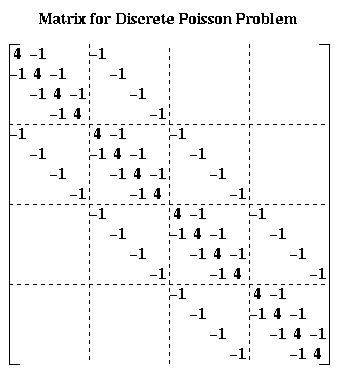

👉 The global matrix structure reflects the **geometry of the grid** and **local interactions**.

---

## 7. Linear algebra insight

The matrix is sparse and structured.

✅  The 2D problem leads to a Kronecker-like structure, which is **key for efficient computation**.

👉 Understanding structure allows us to **design faster solvers**.

---

## 8. Summary

👉  2D PDEs naturally lead to **large sparse systems** where **linear algebra structure** is essential for **efficient computation**.

---
*Heikki Miettinen 2026*